# Scheduling simulator

## Descrição dos experimentos

São conduzidos três experimentos comparativos envolvendo os algoritmos FCFS, SJF não-preemptivo, SJF preemptivo, Prioridade e Round Robin, avaliados segundo as seguintes métricas: turnaround médio, tempo médio de espera, tempo médio de resposta e taxa de utilização da CPU.

1. Workload simples (`inputs/workload_simple.json`) — composto por 5 processos com um único burst de CPU cada, sem definição de quantum e sem custo de troca de contexto. Tem caráter de validação inicial, permitindo evidenciar de forma mais nítida as diferenças entre os algoritmos, sem interferência de operações de E/S.
2. Workload realista (`inputs/workload.json`) — composto por 27 processos com bursts de CPU e E/S, prioridades distintas, `quantum = 5` e `context_switch_cost = 1`. Tem por objetivo avaliar o comportamento dos algoritmos sob uma carga mais representativa de cenários reais, contemplando o impacto da troca de contexto sobre a utilização da CPU.
3. Análise de sensibilidade do Round Robin ao quantum — valores de quantum variando entre 1 e 60, executada sobre os 10 workloads e calculando a média por quantum.

Para (1, 2), cada experimento são produzidos o diagrama de Gantt referente a cada algoritmo, gráficos de barras comparando as métricas e tabelas em formato markdown contendo os valores obtidos e os algoritmos vencedores em cada métrica.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))

from models.process.workload import Workload
from shared.constants import COMPARISON_METRICS
from shared.evaluation import pick_winners
from shared.runner import run_simulation
from shared.parser import parse_input
from shared.plots import plot_gantt, plot_metric_bars
from shared.reporter import aggregate_reports
from shared.reporter import print_comparison as print_comparison_shared


In [2]:
def run_simulation_notebook(path):
    workload = parse_input(path)

    results, gantts, reports = run_simulation(workload)

    print_comparison_shared(reports, pick_winners(reports))

    return results, gantts, reports


In [3]:
results, gantts, reports = run_simulation_notebook("inputs/workload_simple.json")

Comparison
algorithm	avg_turnaround	avg_waiting	avg_response	cpu_utilization	throughput
FCFS	9.0000	4.4000	4.4000	1.0000	0.2174
SJF	8.8000	4.2000	4.2000	1.0000	0.2174
SJF (preemptive)	7.8000	3.2000	1.8000	1.0000	0.2174
Priority	9.0000	4.4000	4.4000	1.0000	0.2174
Round Robin	10.2000	5.6000	0.6000	1.0000	0.2174

Winner per metric
  avg_turnaround: SJF (preemptive)
  avg_waiting: SJF (preemptive)
  avg_response: Round Robin
  cpu_utilization: FCFS
  throughput: FCFS


In [4]:
def print_comparison(results, gantts, reports, figure_size=(10, 10)):
    for result, gantt in zip(results, gantts):
        fig, ax = plt.subplots(figsize=figure_size)
        plot_gantt(result, ax=ax, gantt=gantt)
        fig.tight_layout()
        plt.show()
    
    for metric in COMPARISON_METRICS:
        fig, ax = plt.subplots(figsize=(8, 4))
        plot_metric_bars(reports, metric, ax=ax)
        fig.tight_layout()
        plt.show()

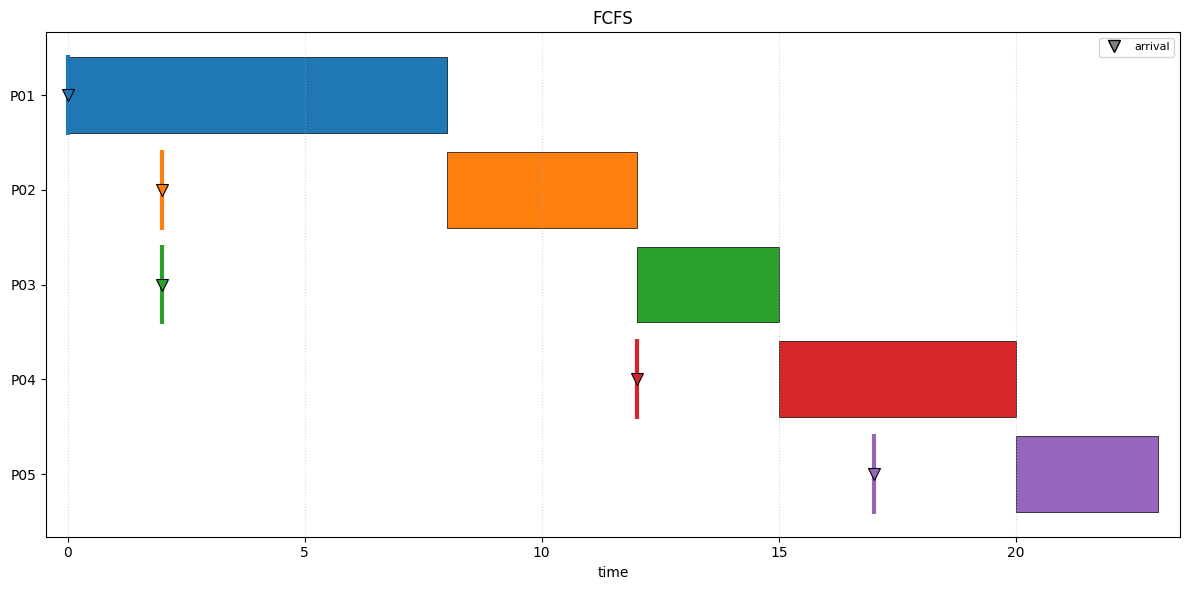

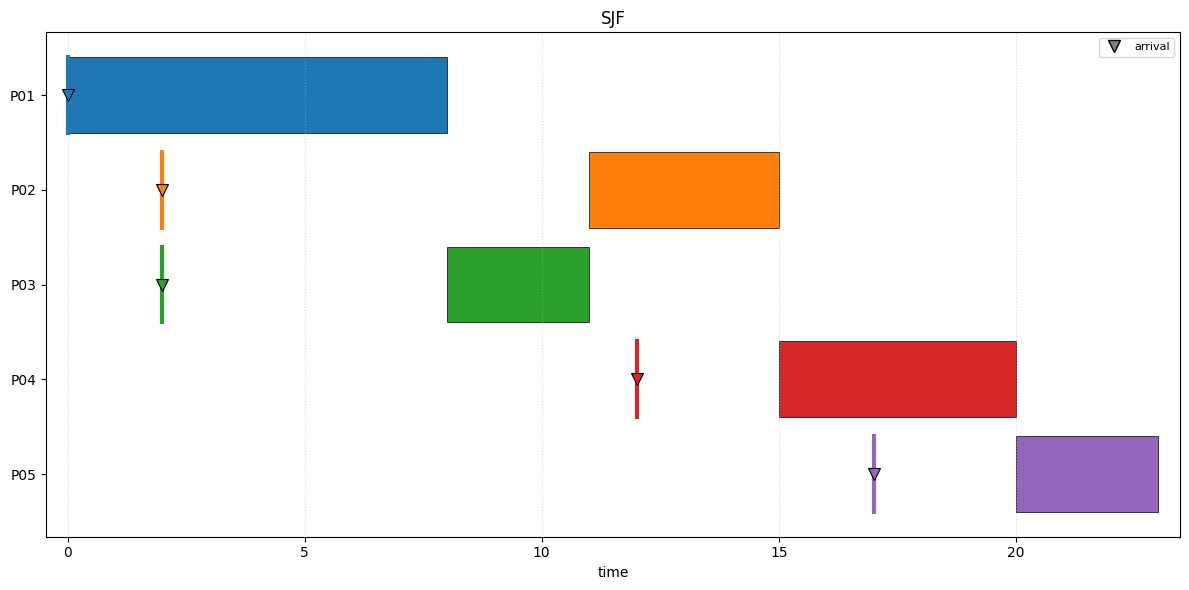

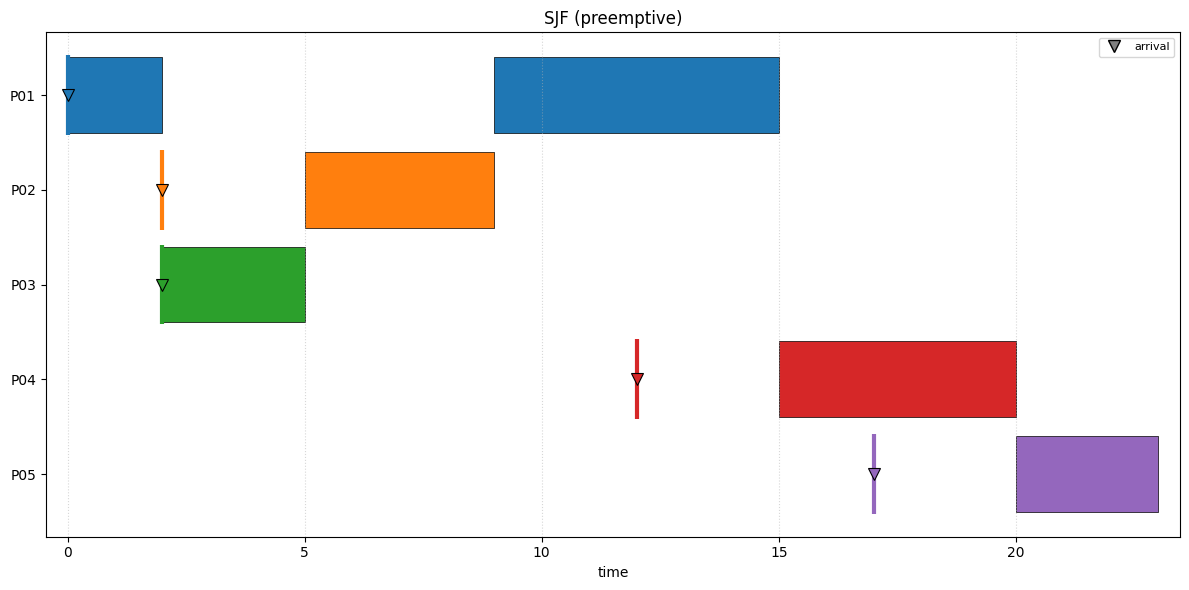

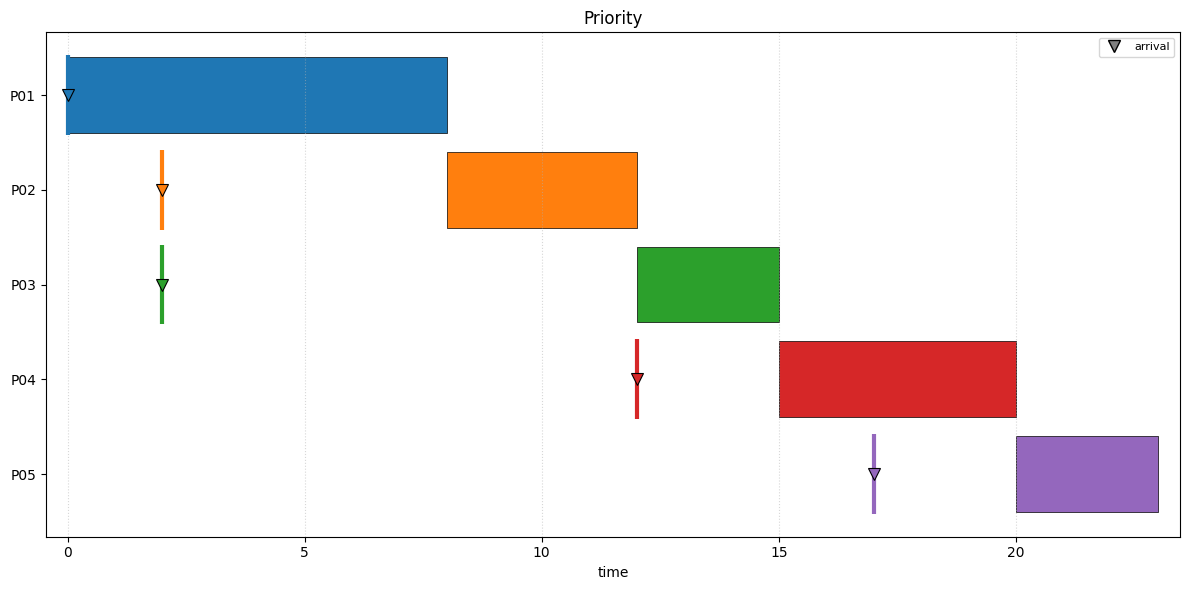

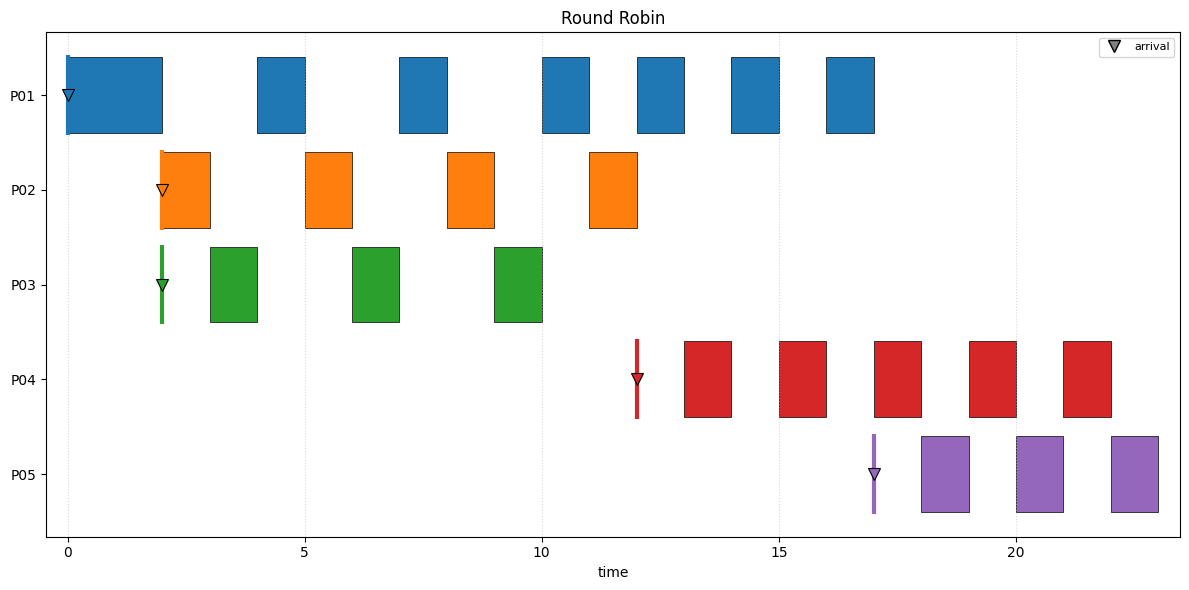

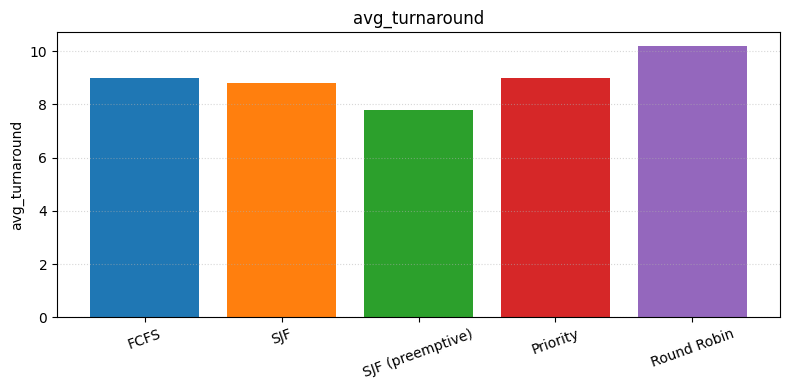

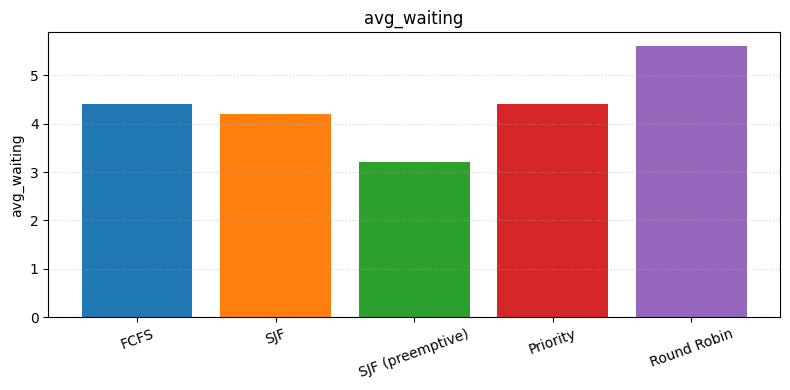

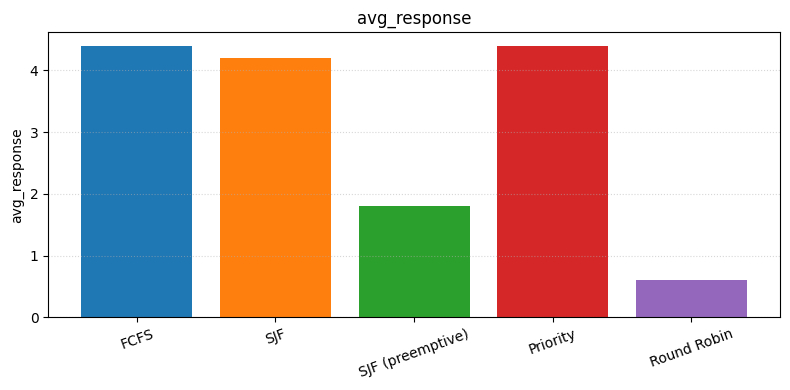

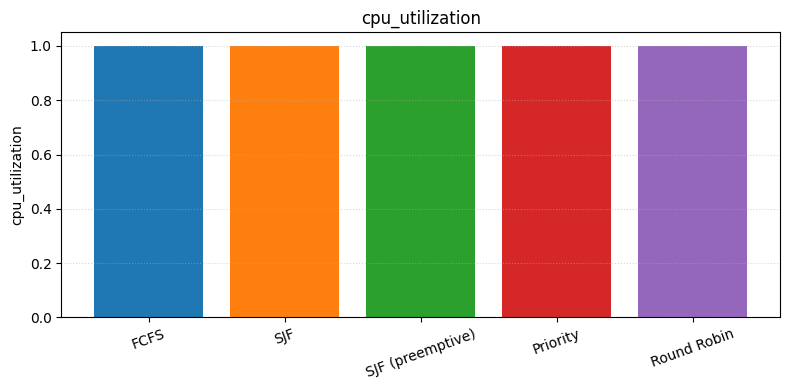

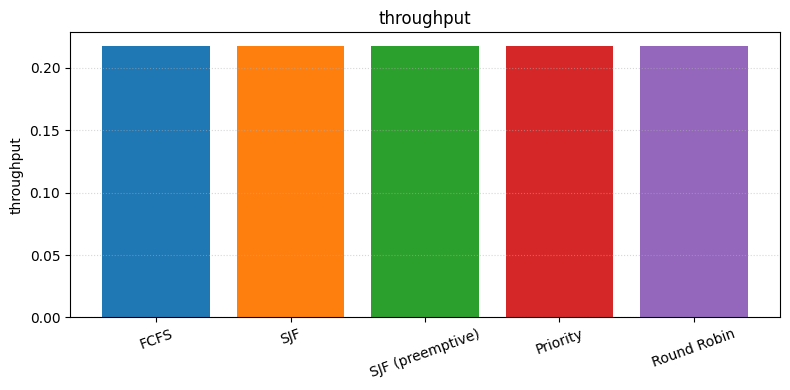

In [5]:
print_comparison(results, gantts, reports, (12,6))

## Comparação entre algoritmos

Métricas médias (workload padrão do `inputs/workload_simple.json`).

### Mesmos números em tabela Markdown

| Algoritmo | Avg. turnaround | Avg. waiting | Avg. response | CPU utilization |
| :-- | --: | --: | --: | --: |
| FCFS | 9.0000 | 4.4000 | 4.4000 | 1.0000 |
| SJF | 8.8000 | 4.2000 | 4.2000 | 1.0000 |
| SJF (preemptive) | 7.8000 | 3.2000 | 1.8000 | 1.0000 |
| Priority | 9.0000 | 4.4000 | 4.4000 | 1.0000 |
| Round Robin | 10.2000 | 5.6000 | 0.6000 | 1.0000 |

### Melhor por métrica

| Métrica | Vencedor |
| :-- | :-- |
| `avg_turnaround` | SJF (preemptive) |
| `avg_waiting` | SJF (preemptive) |
| `avg_response` | Round Robin |
| `cpu_utilization` | FCFS |


In [6]:
results, gantts, reports = run_simulation_notebook("inputs/workload.json")

Comparison
algorithm	avg_turnaround	avg_waiting	avg_response	cpu_utilization	throughput
FCFS	71.2222	65.7778	37.5926	0.7143	0.1753
SJF	58.2593	52.8148	41.3704	0.7143	0.1753
SJF (preemptive)	58.1481	52.7037	40.3333	0.7051	0.1731
Priority	65.0370	59.5926	52.7037	0.7097	0.1742
Round Robin	77.6296	72.1852	35.7778	0.6962	0.1709

Winner per metric
  avg_turnaround: SJF (preemptive)
  avg_waiting: SJF (preemptive)
  avg_response: Round Robin
  cpu_utilization: FCFS
  throughput: FCFS


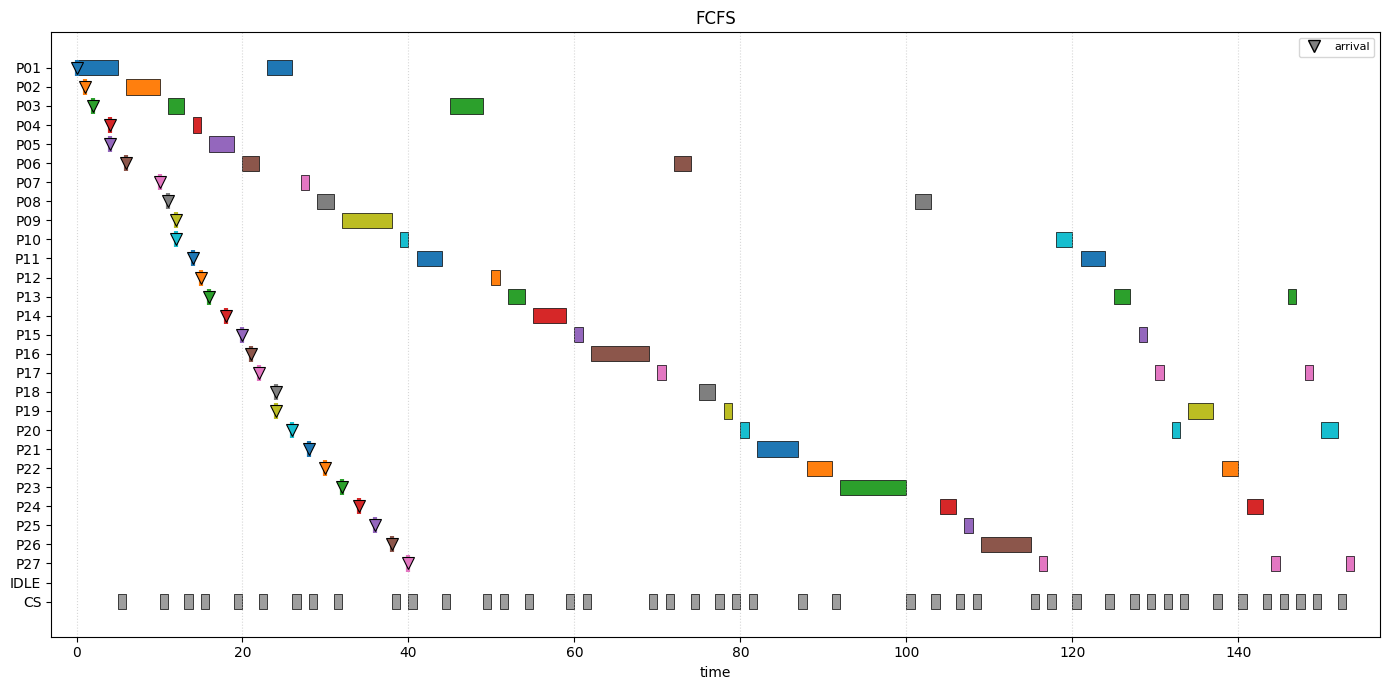

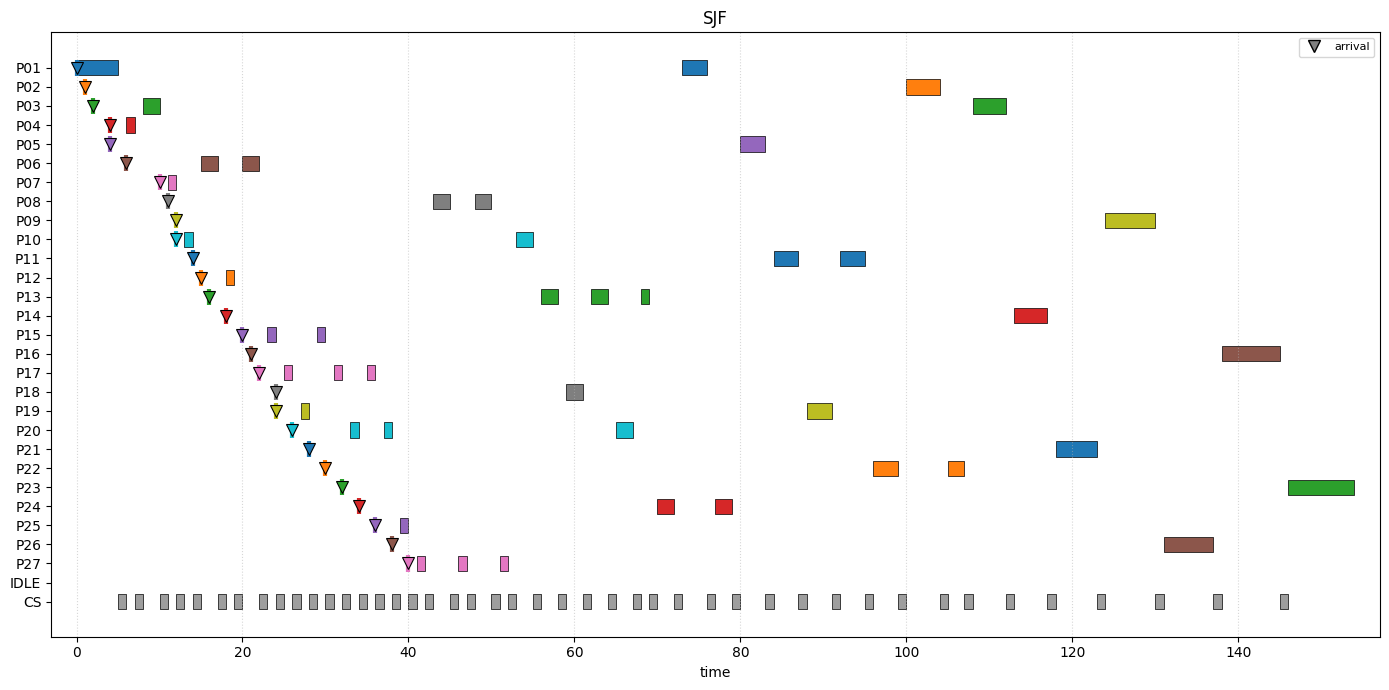

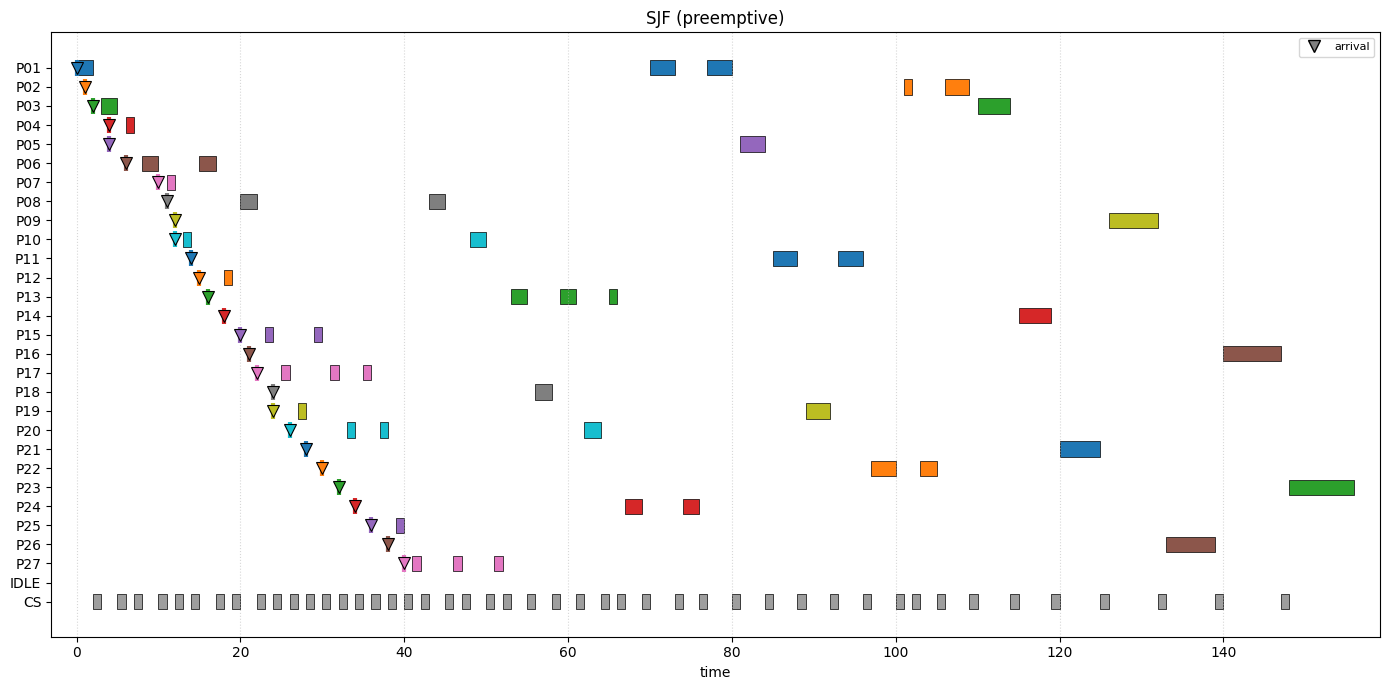

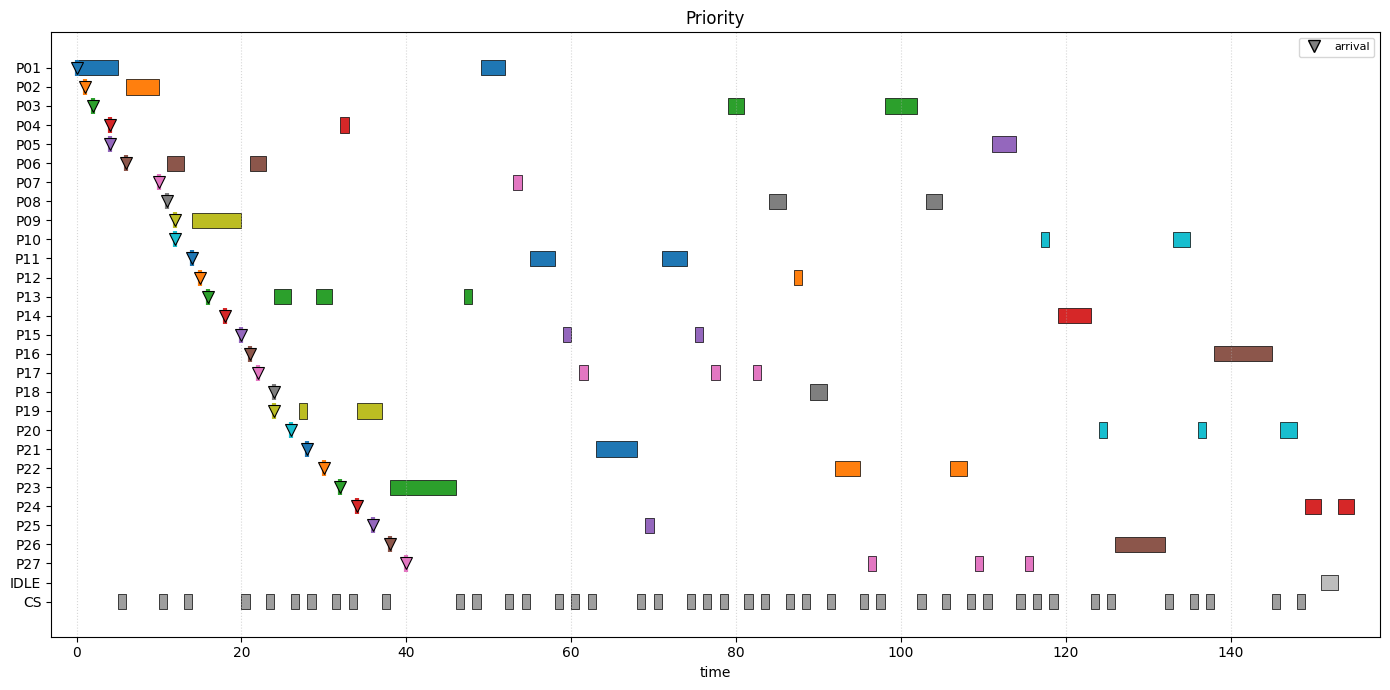

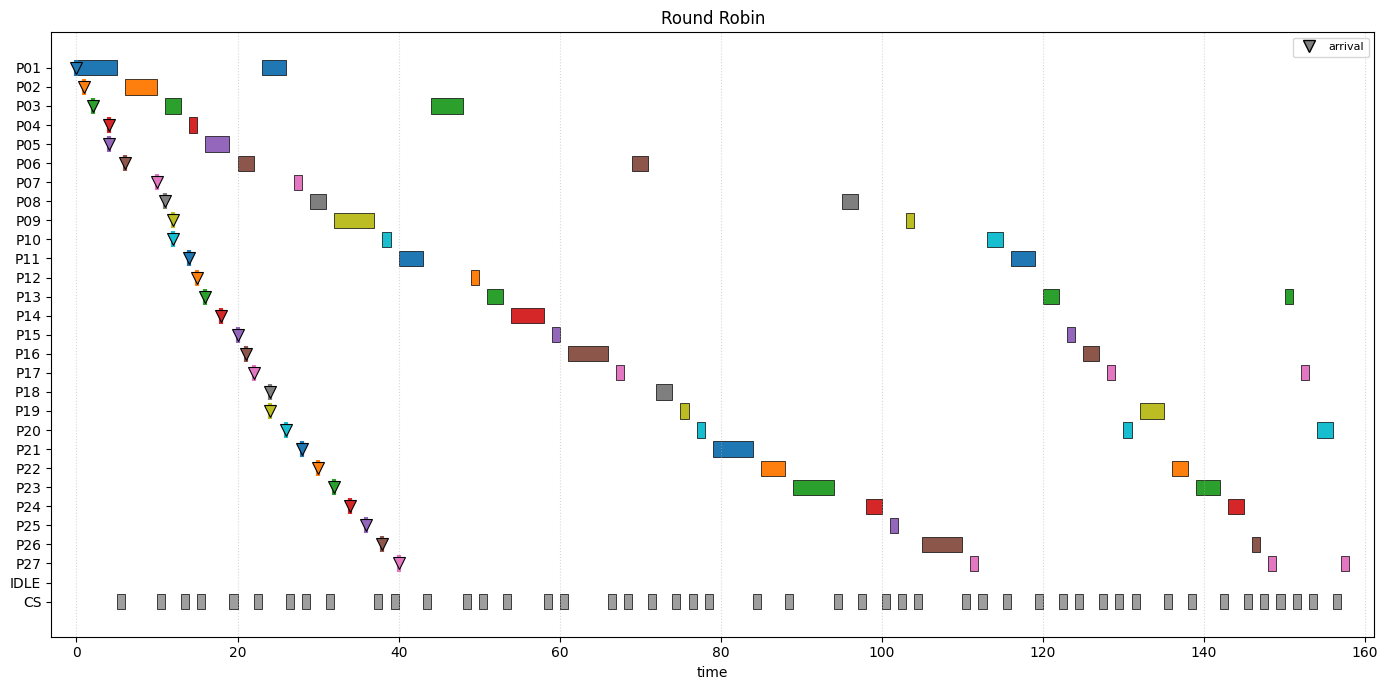

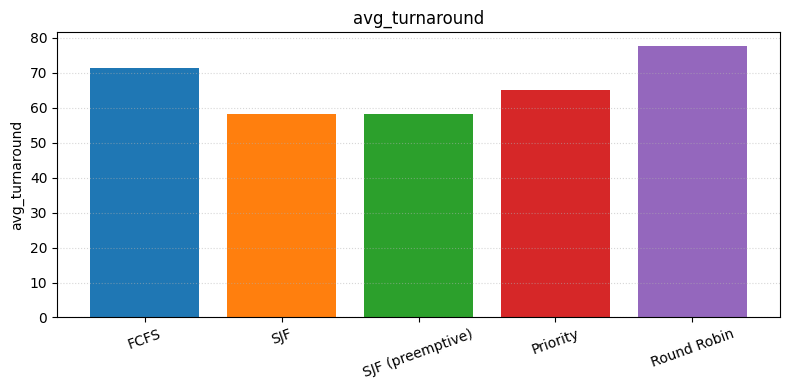

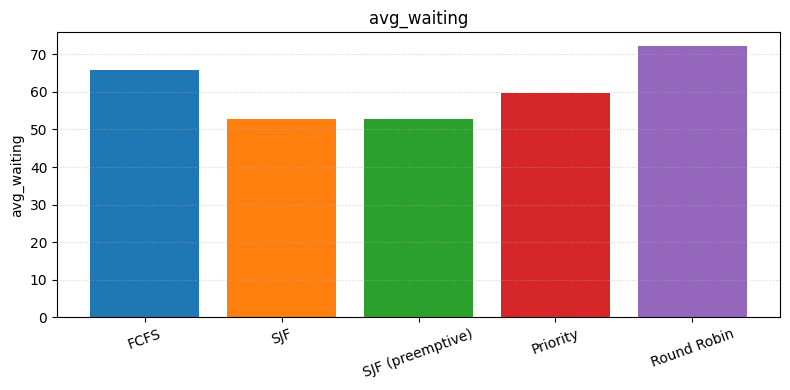

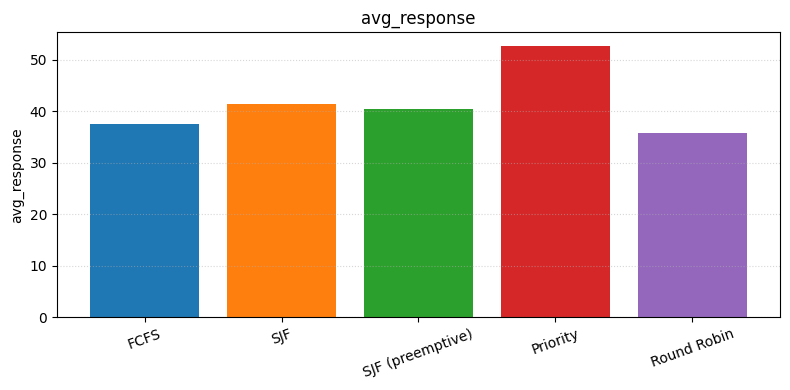

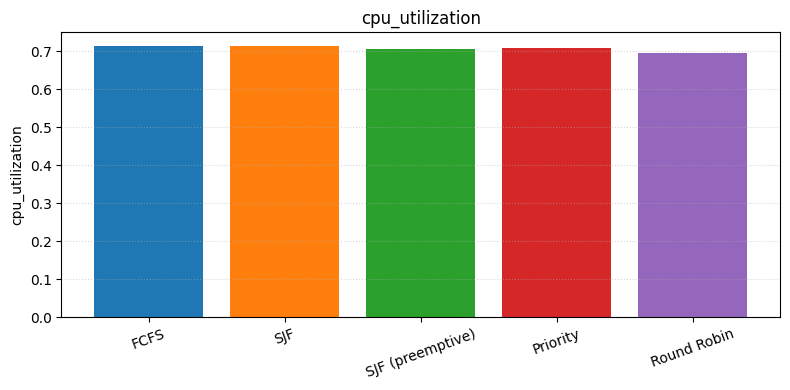

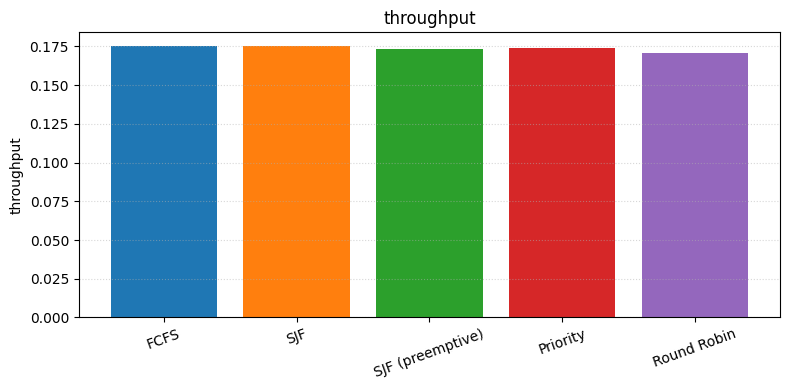

In [7]:
print_comparison(results, gantts, reports, (14,7))


## Comparação entre algoritmos

Métricas médias (workload padrão do `inputs/workload.json`).

### Mesmos números em tabela Markdown

| Algoritmo | Avg. turnaround | Avg. waiting | Avg. response | CPU utilization |
| :-- | --: | --: | --: | --: |
| FCFS | 71.2222 | 65.7778 | 37.5926 | 0.7143 |
| SJF | 58.2593 | 52.8148 | 41.3704 | 0.7143 |
| SJF (preemptive) | 58.1481 | 52.7037 | 40.3333 | 0.7051 |
| Priority | 65.0370 | 59.5926 | 52.7037 | 0.7097 |
| Round Robin | 77.6296 | 72.1852 | 35.7778 | 0.6962 |

### Melhor por métrica

| Métrica | Vencedor |
| :-- | :-- |
| `avg_turnaround` | SJF (preemptive) |
| `avg_waiting` | SJF (preemptive) |
| `avg_response` | Round Robin |
| `cpu_utilization` | FCFS |


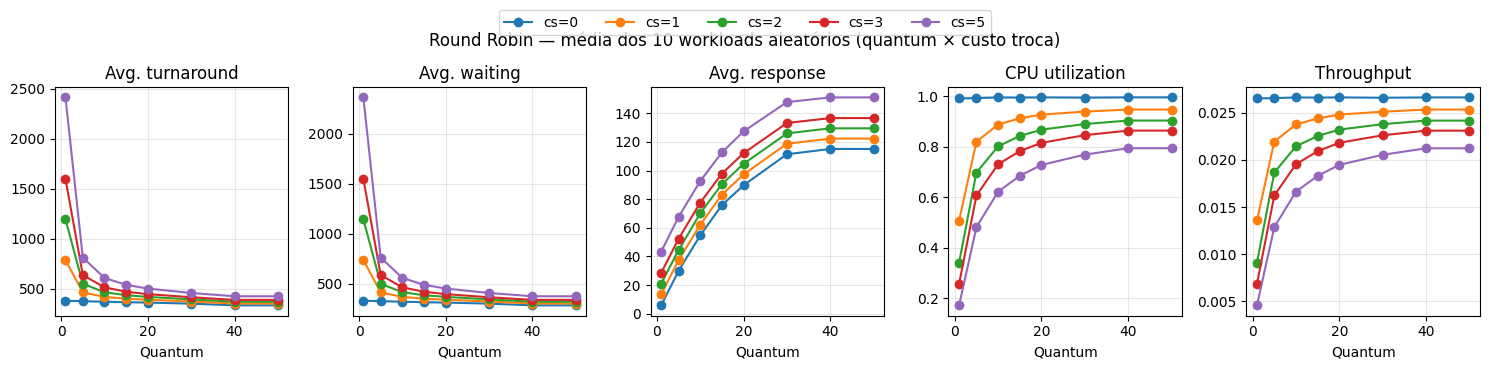

In [8]:
WORKLOAD_RANDOM_JSON = tuple(f"inputs/workload_random_{i:02d}.json" for i in range(1, 11))
QUANTUMS = (1, 5, 10, 15, 20, 30, 40, 50)
# Cinco cenários de custo de troca de contexto (ticks): livre, típico, moderado, pesado.
CONTEXT_SWITCH_COSTS = (0, 1, 2, 3, 5)

rr_by_quantum_cs = {}
for cs in CONTEXT_SWITCH_COSTS:
    rr_by_quantum_cs[cs] = {}
    for q in QUANTUMS:
        runs = []
        for path in WORKLOAD_RANDOM_JSON:
            base = parse_input(path)
            workload = Workload(
                base.processes,
                quantum=q,
                context_switch_cost=cs,
            )
            _, _, reports = run_simulation(workload, algo="round-robin")
            runs.append(reports)
        rr_by_quantum_cs[cs][q] = aggregate_reports(runs)[0]

xs = list(QUANTUMS)
metric_titles = (
    "Avg. turnaround",
    "Avg. waiting",
    "Avg. response",
    "CPU utilization",
    "Throughput",
)
fig, axes = plt.subplots(
    1,
    len(COMPARISON_METRICS),
    figsize=(3 * len(COMPARISON_METRICS), 3.5),
    sharex=True,
)
for ax, metric, title in zip(axes, COMPARISON_METRICS, metric_titles):
    for cs in CONTEXT_SWITCH_COSTS:
        ys = [getattr(rr_by_quantum_cs[cs][q], metric) for q in QUANTUMS]
        ax.plot(xs, ys, marker="o", label=f"cs={cs}")
    ax.set_title(title)
    ax.set_xlabel("Quantum")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(CONTEXT_SWITCH_COSTS),
    bbox_to_anchor=(0.5, 1.06),
)
fig.suptitle("Round Robin — média dos 10 workloads aleatórios (quantum × custo troca)")
fig.tight_layout()
plt.subplots_adjust(top=0.82)
plt.show()

### Constata-se que:

1. Turnaround e throughput tem comportamento inversamente proporcional, em quantums menores o tempo de execução é maior, uma vez que se preempta muito mais, como mostrado no primeiro gráfico. O custo de troca influência no deslocamento do grafico de throughput, uma vez que, menor custo de preemptação leva ao aumentar o tempo de utilização do CPU.
2. Quantums menores preemptam mais, refletindo em maior tempo de espera. Paralelamente, quanto maior o custo de troca, maior será a espera.
3. O tempo de resposta é menor em quantums menores pela preempção mais rápida, porém estagna em um valor alto após incrementado o tamanho do quantum, principalmente ao quantum maior ou igual a média de tempo de burst. 

## Conclusão

Após apresentados diversos cenários com suas particularidades, podemos notar comportamentos signitificamente semelhantes em alguns casos, como por exemplo.

1. Round Robin apresenta menor tempo de resposta em diversos experimentos.
2. SJF apresenta o menor ou segundo menor tempo total de execução.
3. SJF apresenta o menor tempo de espera.
4. O algoritmo Round Robin tem comportamento diverso dependendo dos parametros, o menor tempo de espera e tempo total de execução médios foram constatados em quantums grandes e troca de contextos pequenas.
